In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, _, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog.fits')

In [3]:
delta_dv = dps_df['dv_r'] - dps_df['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['sigma_l']**2 + resolution**2)

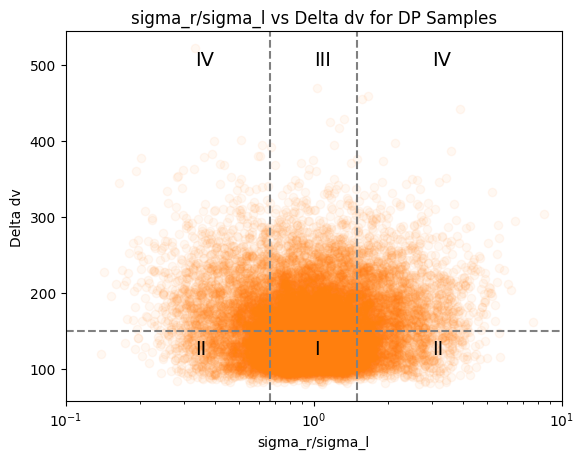

In [4]:
plt.scatter(sigma_r/sigma_l, delta_dv, alpha=.05, color='C1')
plt.text(1, 120, 'I', fontsize=14)
plt.text(1/3, 120, 'II', fontsize=14)
plt.text(3, 120, 'II', fontsize=14)
plt.text(1, 500, 'III', fontsize=14)
plt.text(1/3, 500, 'IV', fontsize=14)
plt.text(3, 500, 'IV', fontsize=14)

plt.axvline(1.5, color='gray', linestyle='--')
plt.axvline(1/1.5, color='gray', linestyle='--')
plt.axhline(150, color='gray', linestyle='--')
plt.xlabel('sigma_r/sigma_l')
plt.ylabel('Delta dv')
plt.title('sigma_r/sigma_l vs Delta dv for DP Samples')
plt.xlim(left=0.1, right=10)
# plt.ylim(bottom=75)
# plt.legend()
plt.xscale('log')
# plt.ylim([0, 500])

plt.show()

In [5]:
sf_dps = pd.read_csv('sf_dps.csv')
agn_dps = pd.read_csv('agn_dps.csv')

In [10]:
delta_dv_sf = sf_dps['dv_r'] - sf_dps['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+sf_dps['Z']))
sigma_r_sf = np.sqrt(sf_dps['sigma_r']**2 + resolution**2)
sigma_l_sf = np.sqrt(sf_dps['sigma_l']**2 + resolution**2)


delta_dv_agn = agn_dps['dv_r'] - agn_dps['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+agn_dps['Z']))
sigma_r_agn = np.sqrt(agn_dps['sigma_r']**2 + resolution**2)
sigma_l_agn = np.sqrt(agn_dps['sigma_l']**2 + resolution**2)

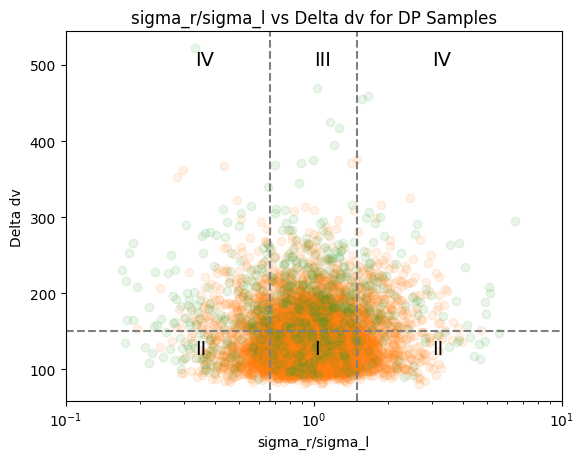

In [11]:
plt.scatter(sigma_r_sf/sigma_l_sf, delta_dv_sf, alpha=.1, color='C1')
plt.scatter(sigma_r_agn/sigma_l_agn, delta_dv_agn, alpha=.1, color='C2')
plt.text(1, 120, 'I', fontsize=14)
plt.text(1/3, 120, 'II', fontsize=14)
plt.text(3, 120, 'II', fontsize=14)
plt.text(1, 500, 'III', fontsize=14)
plt.text(1/3, 500, 'IV', fontsize=14)
plt.text(3, 500, 'IV', fontsize=14)

plt.axvline(1.5, color='gray', linestyle='--')
plt.axvline(1/1.5, color='gray', linestyle='--')
plt.axhline(150, color='gray', linestyle='--')
plt.xlabel('sigma_r/sigma_l')
plt.ylabel('Delta dv')
plt.title('sigma_r/sigma_l vs Delta dv for DP Samples')
plt.xlim(left=0.1, right=10)
# plt.ylim(bottom=75)
# plt.legend()
plt.xscale('log')
# plt.ylim([0, 500])

plt.show()

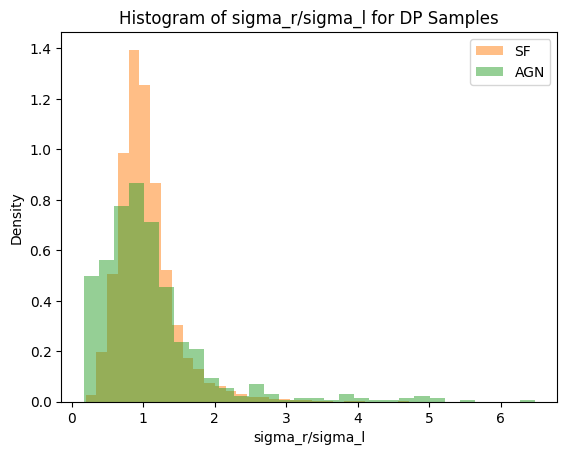

In [12]:
plt.hist(sigma_r_sf/sigma_l_sf, bins=30, alpha=0.5, color='C1', label='SF', density=True)
plt.hist(sigma_r_agn/sigma_l_agn, bins=30, alpha=0.5, color='C2', label='AGN', density=True)
plt.xlabel('sigma_r/sigma_l')
plt.ylabel('Density')
plt.title('Histogram of sigma_r/sigma_l for DP Samples')
plt.legend()
plt.show()

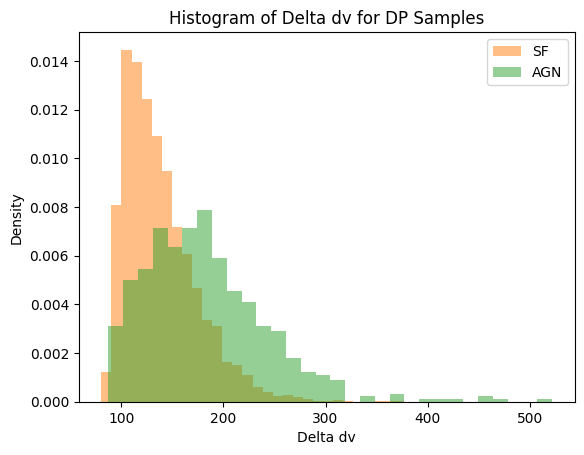

In [13]:
plt.hist(delta_dv_sf, bins=30, alpha=0.5, color='C1', label='SF', density=True)
plt.hist(delta_dv_agn, bins=30, alpha=0.5, color='C2', label='AGN', density=True)
plt.xlabel('Delta dv')
plt.ylabel('Density')
plt.title('Histogram of Delta dv for DP Samples')
plt.legend()
plt.show()